<a href="https://colab.research.google.com/github/Jhoniisjelly/Data201_JhonathanUrquilla/blob/main/Assignment_Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Week 4

###### Jhonathan Urquilla

In [1]:

#Loading libraries to use
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
#Loading the dataset to use
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


# Part E - Explore the Dataset
Before modeling, briefly explore the data.

Create at least three plots such as:

Histogram of price
1. Scatter plot: size vs price
2. Boxplot: price by neighborhood
3. Bar chart: housing type

Text(0, 0.5, '# of Houses')

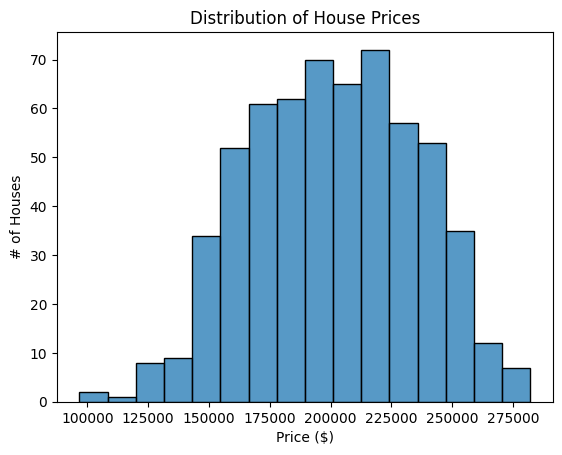

In [3]:
sns.histplot(data= df, x= "price")
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("# of Houses")

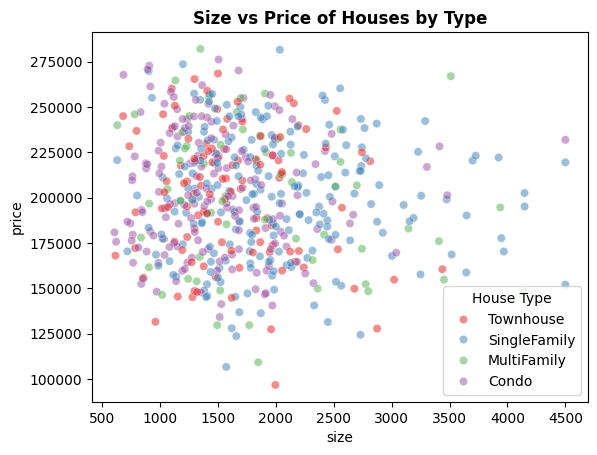

In [10]:
sns.scatterplot(data = df, x = "size", y = "price", hue = "type", alpha = 0.5, palette = "Set1")
plt.title("Size vs Price of Houses by Type", fontweight = "bold")
plt.legend(title = "House Type")
plt.show()

Text(0, 0.5, 'Price ($)')

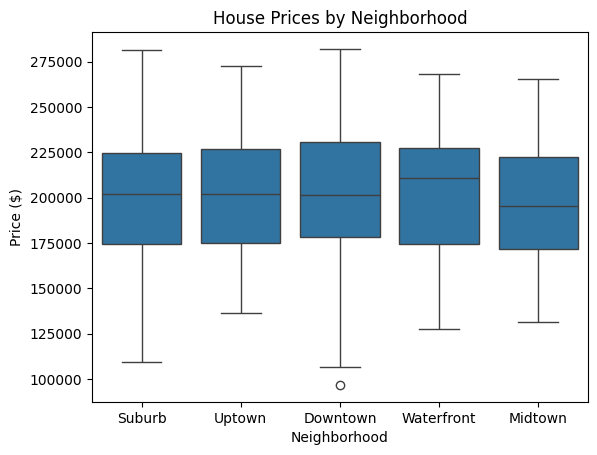

In [9]:
sns.boxplot(data=df, x="neighborhood", y="price")
plt.title("House Prices by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price ($)")

### Discuss one interesting pattern you observe.

##### looking at the Scatter plot I find it pretty interesting how when it comes to size most of the houses are roughtly around the 1000 to 2000. Thought when it comes to Single family homes, it seems they have more seperation from the others and they bleed out above 2000. I would have at least expected a multi family home to have this spread opposed to the Signle family home.

# Step 0 - Create a Binary Outcome

In [11]:
df["high_price"] = (df["price"] > df["price"].median()).astype(int)
df

,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0
...,...,...,...,...,...,...,...
595,100596,232811.0,1443.241197,3.0,Midtown,Condo,1
596,100597,235624.0,1083.909714,2.0,Suburb,Condo,1
597,100598,244889.0,1600.126432,1.0,Suburb,SingleFamily,1
598,100599,239545.0,1248.216637,1.0,Waterfront,Condo,1


# Part A - Logistic Regression for Inference

#### In Python

#### Fit the equivalent model using statsmodels.

### Example:

#### import statsmodels.formula.api as smf

#### model = smf.logit(
##### "high_price ~ size + bedrooms + C(neighborhood)",
##### data=df
##### ).fit()

##### print(model.summary())

### Report

# Create a table including:

1. coefficients
2. odds ratios
3. p-values

### Odds ratios:

##### odds_ratio = exp(coefficient)

In [15]:
housing = smf.logit("high_price ~ size + bedrooms + C(neighborhood) + C(type)", data=df).fit()
housing.summary()

Optimization terminated successfully.
         Current function value: 0.683349
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                 0.01414
Time:                        23:23:37   Log-Likelihood:                -358.07
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.3292
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.2590      0.309      0.837      0.403      -0.347       0.866
C(neighborhood)[T.Midtown]       -0.2657      0.286     -0.931      0.352      -0.825       0.294
C(neighborhood)[T.Suburb]         0.1402      0.258      0.544      0.587      -0.365       0.645
C(neighborhood)[T.Uptown]         0.0552      0.277      0.199      0.842      -0.488       0.599
C(neighborhood)[T.Waterfront]     0.4327      0.356      1.217      0.224      -0.264       1.130
C(type)[T.MultiFamily]            0.0079      0.319      0.025      0.980      -0.617       0.633
C(type)[T.SingleFamily]           0.1169      0.225      0.520      0.603      -0.324       0.557
C(type)[T.Townhouse]              0.3204      0.257      1.245      0.213      -0.184       0.825
size                             -0.0005      0.000     -2.090      0.037      -0.001   -3.28e-05
bedrooms                          0.2308      0.134      1.721      0.085      -0.032       0.494
=================================================================================================
"""

In [16]:
coef = housing.params
odds_ratio = np.exp(coef)
p_value = housing.pvalues
pd.DataFrame({"Coefficient": coef, "Odds ratio": odds_ratio, "P value": p_value})

,Coefficient,Odds ratio,P value
Intercept,0.259034,1.295677,0.402535
C(neighborhood)[T.Midtown],-0.265734,0.766643,0.352048
C(neighborhood)[T.Suburb],0.140164,1.150462,0.586668
C(neighborhood)[T.Uptown],0.055166,1.056716,0.842292
C(neighborhood)[T.Waterfront],0.432651,1.541338,0.223709
C(type)[T.MultiFamily],0.007946,1.007977,0.980126
C(type)[T.SingleFamily],0.116854,1.123955,0.603092
C(type)[T.Townhouse],0.320389,1.377664,0.213238
size,-0.000525,0.999475,0.036582
bedrooms,0.230827,1.259642,0.085279


#### In this case Size is the only predictor that is statistically significant because its p-value of 0.037 falls below 0.05.

#### The highest odds ratio, which is 1.54, is found in the Waterfront neighborhood, this indicates a 54% increase in the likelihood of a "high price" Waterfront home.

# Part B - Interpretation (Plain Language)

#### The likelihood of an event—in this case, the house's high price—occurs when an odd ratio is greater than 1. Instead, the odds are reduced when it is less than 1. The odds ratio for the bedrooms variable is 1.26. The likelihood that a house will be expensive rises by 26% for each extra bedroom.

# Part C - Prediction Workflow

1. 1. Train/Test Split

In [30]:
df = df.dropna()
X = df[["size", "bedrooms", "neighborhood", "type"]]
y = df["high_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

2. Fit Logistic Regression

In [31]:
model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##### **In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.**

##### **On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

**3. Evaluate the model**

#### Report:

1. Accuracy
2. ROC-AUC

In [34]:
y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("accuracy:", accuracy)
print("roc_auc:", roc_auc)


accuracy: 0.4666666666666667
roc_auc: 0.43936092955700795


# Part D - Model Understanding

##### Accuracy vs AUC

1. Unlike accuracy, which takes into account a single threshold (usually 0.5), Roc-auc takes into account all potential thresholds. In contrast to accuracy, roc-auc can provide you with a more comprehensive and realistic model performance.

2. I would use statsmodel for policy analysis since it provides information like the coefficient, p-value, and confidence intervals and enables us to see the relationship between variables. Since scikit-learn is primarily intended for data prediction and model performance evaluation, I would use it for prediction tasks.